<a href="https://colab.research.google.com/github/PollyHsu2004/DIP/blob/main/DIP_256.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/PollyHsu2004/DIP.git

Cloning into 'DIP'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 86 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 13.58 MiB | 22.76 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
!ls
%cd DIP
!ls

DIP  sample_data
/content/DIP
 apple_grayscale_jet.mat   environment.yml		  ReadMe.txt
 apple.ipynb		  'environment - 複製.yml'	  reconstruct.mat
 data			   low_res_airplane_jet.mat	  test1.ipynb
 DIP.ipynb		   low_res_airplane_neg_pos.mat   test_I.mat
 DIP_result_fixkerf.png    models			  test.py
 DIP_test_0701.ipynb	   output_256.png		  test_RF.mat
 DIP_test.ipynb		   README.md			  utils


In [ ]:
# run under DIP environment
import os
import skimage.io as io
import scipy.io as sio
import numpy as np
import time
# import math

## Load Data

DD_PARS_blood (from out lab)

In [ ]:
# file_name  = 'data\DD_PARS\DD_PARS_blood.mat'
file_name = r"test_RF.mat"
mat = sio.loadmat(file_name)
print(mat.keys())
img_down = mat["test"]
original_x, original_y = img_down.shape
print(original_x, original_y)
print(img_down)



dict_keys(['__header__', '__version__', '__globals__', 'test'])
2200 128
[[ 0. -0.  0. ...  0. -0.  0.]
 [-0. -0.  0. ...  0. -0. -0.]
 [-0. -0.  0. ...  0.  0. -0.]
 ...
 [ 0.  0. -0. ...  0. -0. -0.]
 [ 0. -0. -0. ... -0. -0.  0.]
 [ 0. -0.  0. ... -0. -0.  0.]]


In [ ]:
from utils.expand_data import *
img_masked, img_mask = expand_data(img_down, original_x, original_y*2)

Plot the loaded data

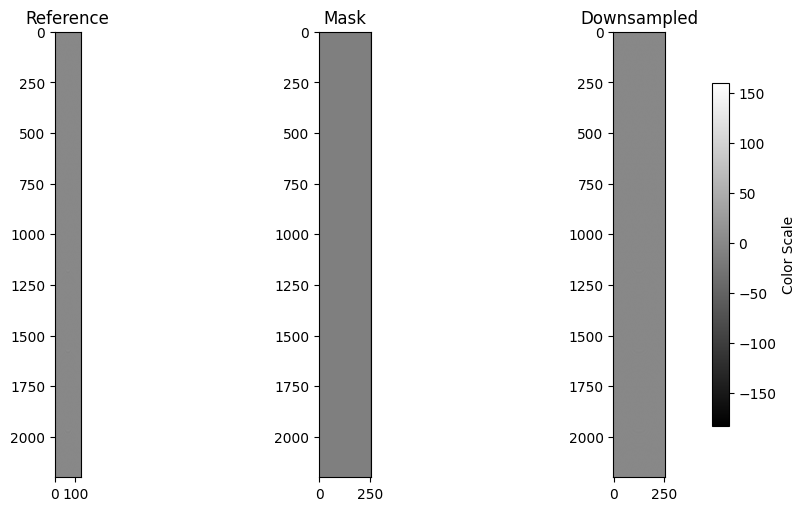

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 5), constrained_layout=True)

colormap = 'gray'
# plot each image
im1 = axes[0].imshow(img_down, cmap=colormap)
axes[0].set_title("Reference")

im2 = axes[1].imshow(img_mask, cmap = 'gray')
axes[1].set_title("Mask")

im3 = axes[2].imshow(img_masked,cmap=colormap)
axes[2].set_title("Downsampled")

# add colorbars
cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Color Scale")

plt.show()


## Pre-work of DIP

In [ ]:
import torch
import torch.optim
torch.__version__

'2.6.0+cu124'

Set inputs, hyperparameters and network architecture

In [ ]:
img_np = np.expand_dims(img_masked, 0)  # expand the downsampled image to 3D numpy array (1, H, W)
mask_np = np.expand_dims(img_mask, 0)   # expand the mask to 3D numpy array (1, H, W)

from models.skip import skip
from utils.inpainting_utils import *

#from skimage.measure import compare_psnr,compare_ssim
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

PLOT = True
imsize = -1
dim_div_by = 64

# setup
pad = 'reflection' # 'zero'
OPT_OVER = 'net'
OPTIMIZER = 'adam'
# Same params and net as in super-resolution and denoising
INPUT = 'noise'
input_depth = 32
LR = 0.001
num_iter = 1000
param_noise = False
show_every = 50
save_every = 10
figsize = 5
reg_noise_std = 0.03

net = skip(input_depth, img_np.shape[0],
           num_channels_down = [original_y*2] * 5,
           num_channels_up =   [original_y*2] * 5,
           num_channels_skip =    [4] * 5,
           filter_size_up = 3, filter_size_down = 3,
           upsample_mode='bilinear', filter_skip_size=1,
           need_sigmoid=False, need_bias=True, pad=pad, act_fun='LeakyReLU').type(dtype)


net = net.type(dtype)
net_input = get_noise(input_depth, INPUT, img_np.shape[1:]).type(dtype) # generate a random noise input tensor (1, input_depth, H, W)
# Compute number of parameters
s  = sum(np.prod(list(p.size())) for p in net.parameters())
print ('Number of params: %d' % s)

# Loss
mse = torch.nn.MSELoss().type(dtype)

img_var = np_to_torch(img_np).type(dtype)   # convert numpy array to torch tensor (1, 1, H, W)
mask_var = np_to_torch(mask_np).type(dtype) # convert numpy array to torch tensor (1, 1, H, W)


Number of params: 8727525


In [ ]:
print(img_var.shape)
print(mask_var.shape)

torch.Size([1, 1, 2200, 256])
torch.Size([1, 1, 2200, 256])


Create the numpy to save the reults for each [save_every] iteration and processing time (in second)

In [ ]:
out_log_np = np.zeros(shape = (num_iter//save_every, img_masked.shape[0], img_masked.shape[1]))
time_log_np = np.zeros(shape = (1, num_iter//save_every))

show the input noise

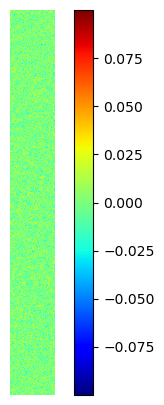

In [ ]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(torch_to_np(net_input).transpose(1, 2, 0)[:,:,0], cmap='jet')
plt.colorbar()

# DIP process

Starting optimization with ADAM


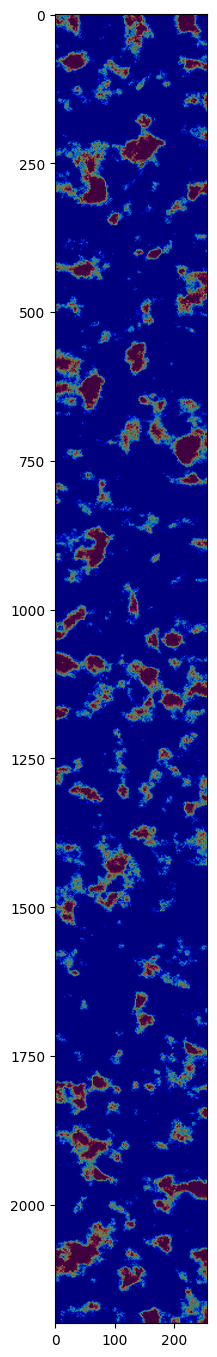

Elasped time:43.341
Elasped time:54.421
Elasped time:65.107
Elasped time:75.577
Elasped time:86.019


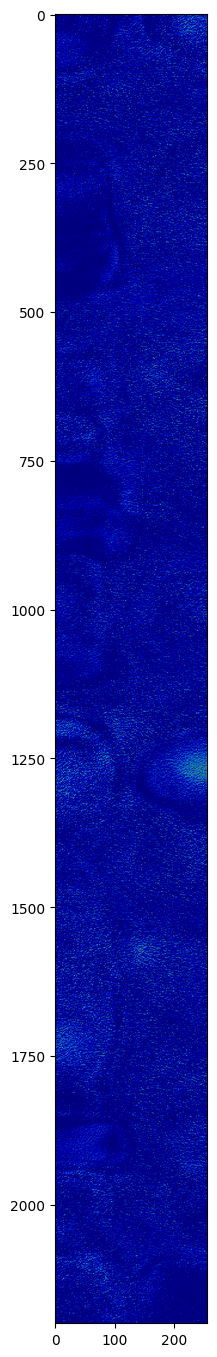

Elasped time:97.176
Elasped time:107.64
Elasped time:118.206
Elasped time:128.745
Elasped time:139.45


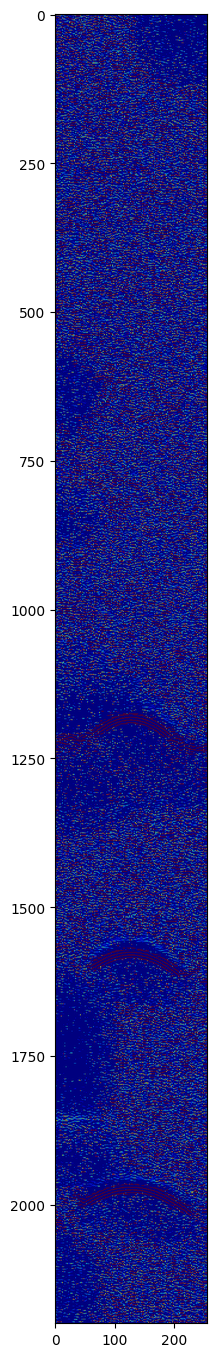

Elasped time:150.784
Elasped time:161.395
Elasped time:171.958
Elasped time:182.569
Elasped time:193.106


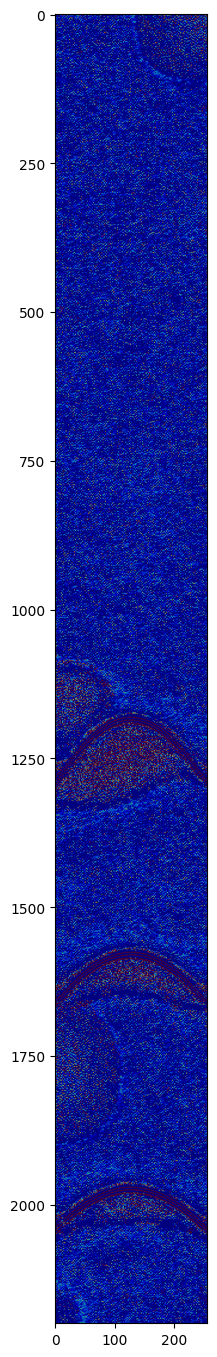

Elasped time:204.449
Elasped time:215.018
Elasped time:225.59
Elasped time:236.197
Elasped time:246.865


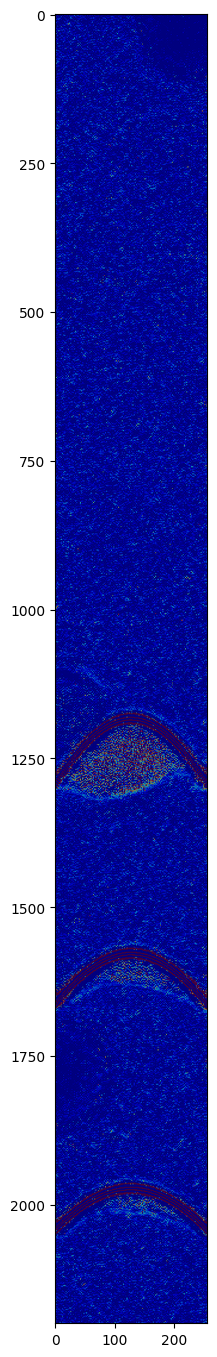

Elasped time:258.278
Elasped time:268.917
Elasped time:279.555
Elasped time:290.18
Elasped time:300.821


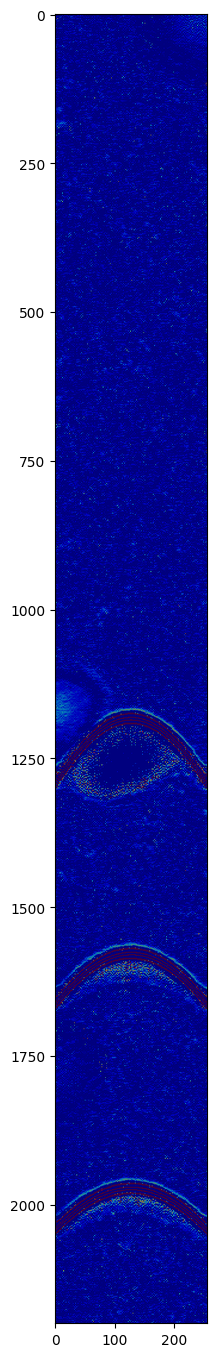

Elasped time:312.596
Elasped time:323.21
Elasped time:333.829
Elasped time:344.452
Elasped time:355.054


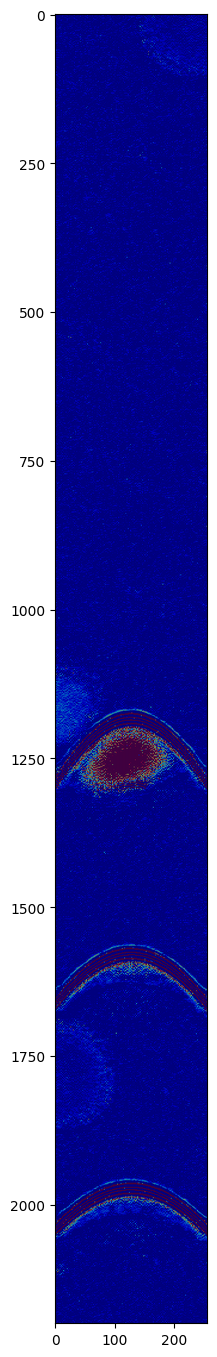

Elasped time:366.386
Elasped time:376.998
Elasped time:387.609
Elasped time:398.298
Elasped time:408.906


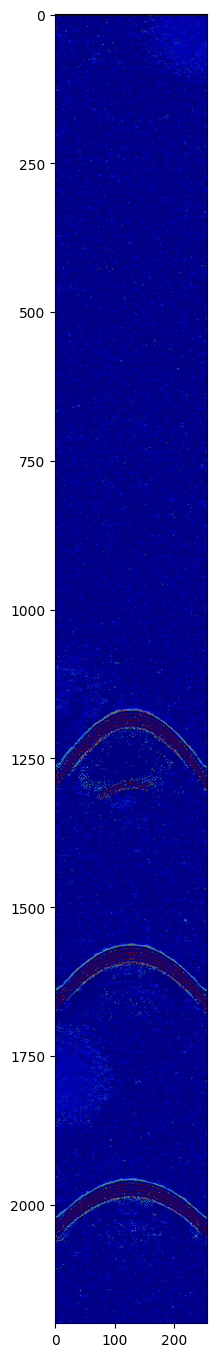

Elasped time:420.492
Elasped time:431.064
Elasped time:441.689
Elasped time:452.419
Elasped time:463.045


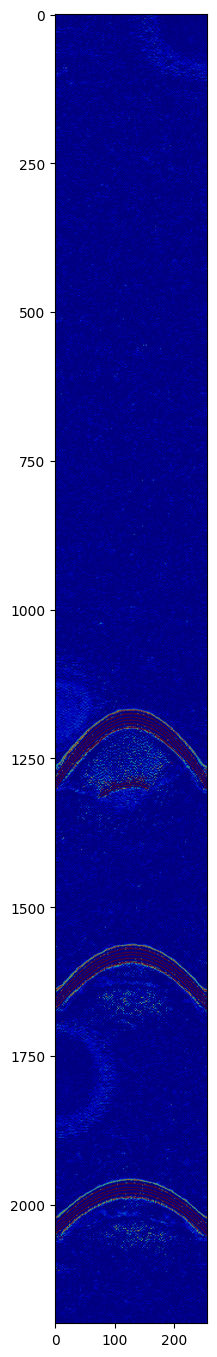

Elasped time:474.384
Elasped time:485.029
Elasped time:495.669
Elasped time:506.297
Elasped time:516.887


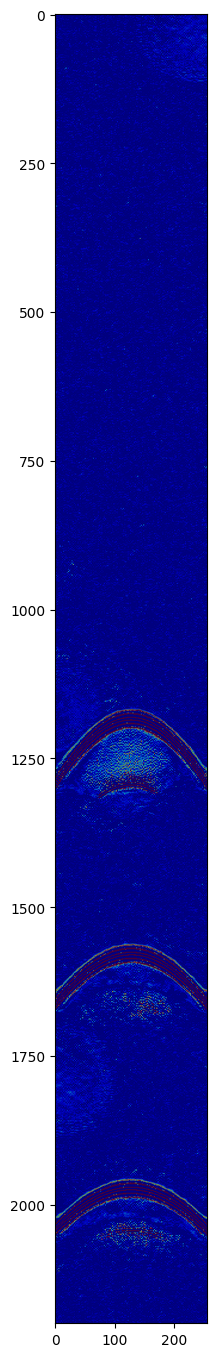

Elasped time:528.442
Elasped time:539.001
Elasped time:549.577
Elasped time:560.203
Elasped time:570.835


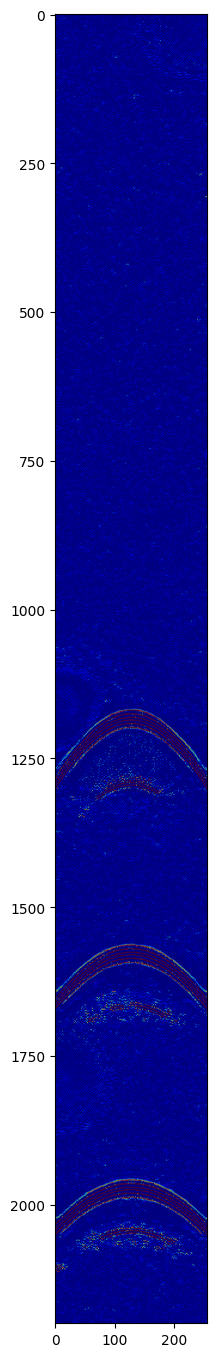

Elasped time:582.197
Elasped time:592.794
Elasped time:603.47
Elasped time:614.111
Elasped time:624.718


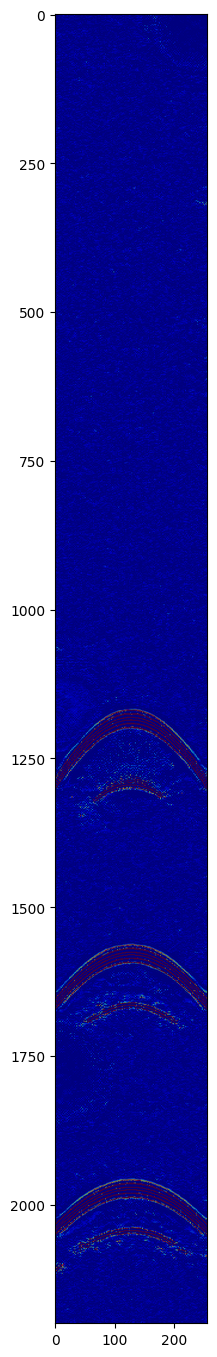

Elasped time:636.013
Elasped time:646.644
Elasped time:657.248
Elasped time:667.855
Elasped time:678.464


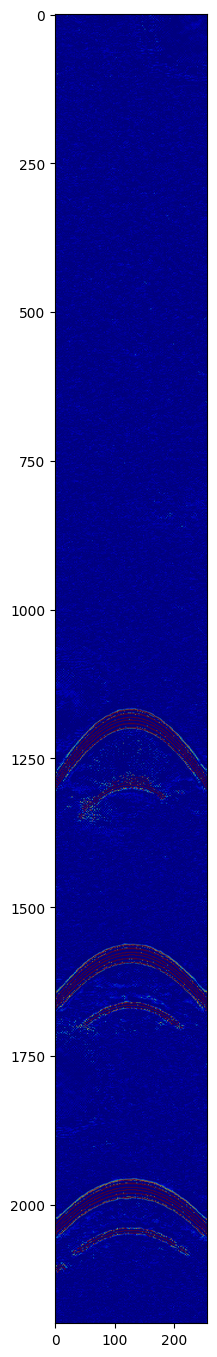

Elasped time:689.79
Elasped time:700.342
Elasped time:710.867
Elasped time:721.484
Elasped time:732.178


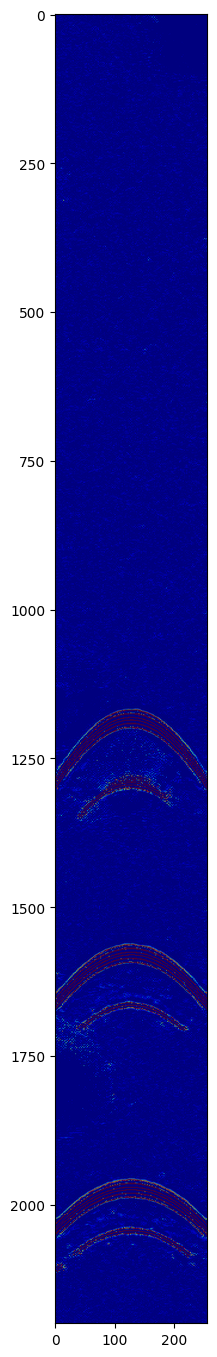

Elasped time:743.533
Elasped time:754.114
Elasped time:764.736
Elasped time:775.377
Elasped time:786.041


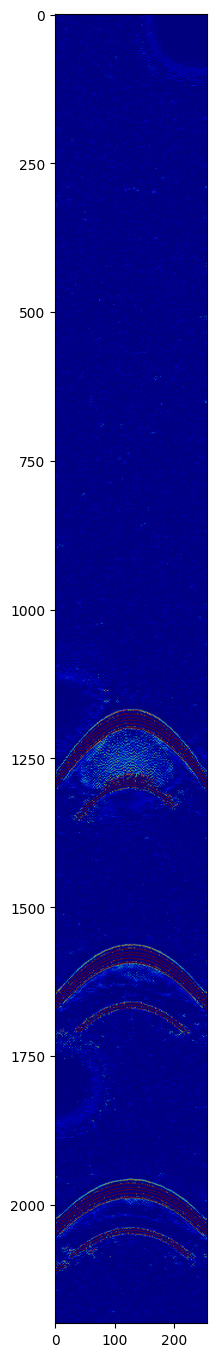

Elasped time:797.77
Elasped time:808.352
Elasped time:818.98
Elasped time:829.58
Elasped time:840.196


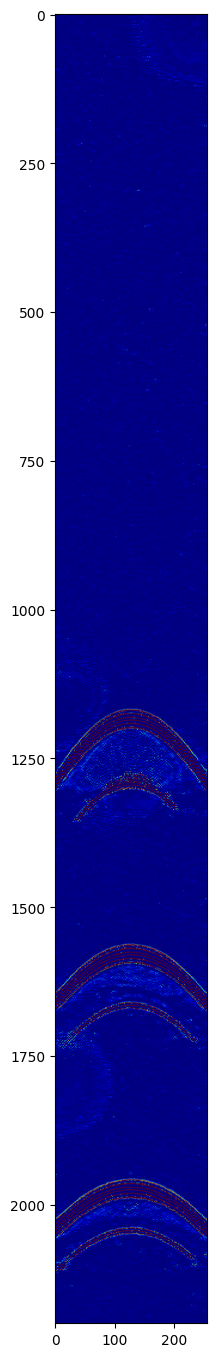

Elasped time:851.529
Elasped time:862.115
Elasped time:872.707
Elasped time:883.305
Elasped time:893.976


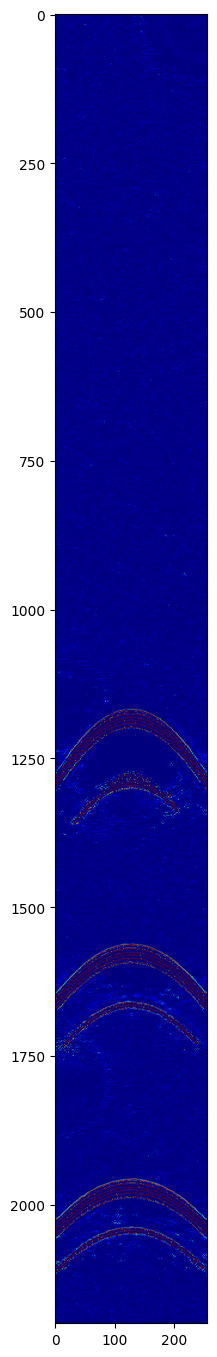

Elasped time:905.492
Elasped time:916.05
Elasped time:926.703
Elasped time:937.311
Elasped time:947.89


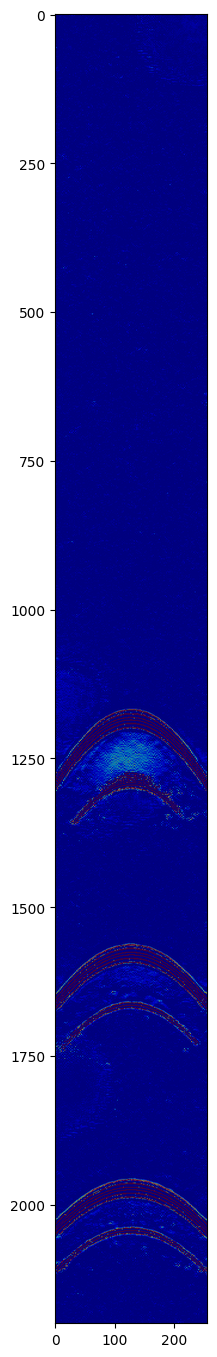

Elasped time:959.277
Elasped time:969.877
Elasped time:980.537
Elasped time:991.106
Elasped time:1001.687


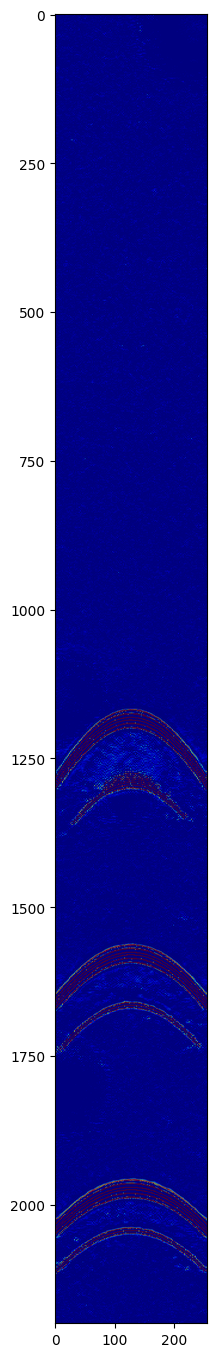

Elasped time:1012.974
Elasped time:1023.545
Elasped time:1034.168
Elasped time:1044.82
Elasped time:1055.427


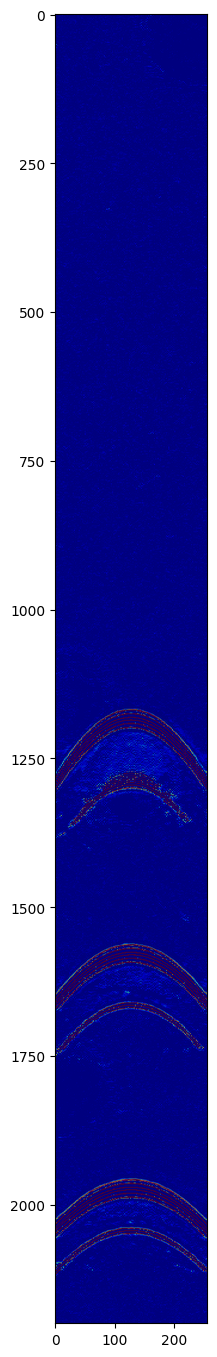

Elasped time:1066.799
Elasped time:1077.409
Elasped time:1088.017
Elasped time:1098.614
Elasped time:1109.286


In [ ]:
# for 256
i = 0
psnr_history = []
loss_history = []
ssim_history = []
def closure():

    global i

    if param_noise:
        for n in [x for x in net.parameters() if len(x.size()) == 4]:
            n = n + n.detach().clone().normal_() * n.std() / 50

    net_input = net_input_saved
    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)


    out_temp = net(net_input)    # output of network (1, 1, H, W)
    x_reshaped = out_temp.view(1, 1, 2200, 128, 2)
    x_summed = torch.sum(x_reshaped, dim=-1)
    out = torch.zeros_like(out_temp)
    out[:, :, :, ::2] = x_summed
    total_loss = mse(out * mask_var, img_var * mask_var)
    total_loss.backward()
    psnr = compare_psnr(img_np, torch_to_np(out), data_range = 1.0)
    ssim = compare_ssim(img_np[0,:], torch_to_np(out)[0,:], data_range = 1.0)
    # History
    loss_history.append(total_loss.item())
    psnr_history.append(psnr)
    ssim_history.append(ssim)

    # print ('Iteration %05d    Loss %f    PSNR %f    SSIM %f' % (i, total_loss.item(), psnr, ssim), '\r', end='')
    print(f'Iteration {i:05d}    Loss {total_loss.item():.4f}    PSNR {psnr:.4f}    SSIM {ssim:.4f}', end='\r')
    if  PLOT and i % show_every == 0:
        out_np = torch_to_np(out)
        plot_image_grid([np.clip(out_np, 0, 1)], factor=figsize, nrow=1)
    if i % save_every == 0:
        out_np = torch_to_np(out)[0,:]
        out_log_np[i//save_every, :, :] = out_np
        print(f'Elasped time:{round(time.time() - start_time, 3)}')
        time_log_np[0, i//save_every] = round(time.time() - start_time, 3)
    i += 1
    return total_loss

start_time = time.time()
net_input_saved = net_input.detach().clone()
noise = net_input.detach().clone()
p = get_params(OPT_OVER, net, net_input)
optimize(OPTIMIZER, p, closure, LR, num_iter)
# optimize(OPTIMIZER, p, closure, LR, 2)

Show the final output of DIP

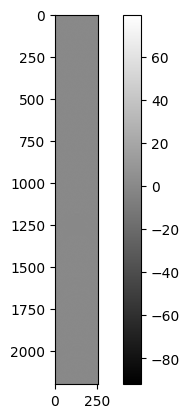

In [ ]:
img_out = torch_to_np(net(net_input))[0,:]
plt.imshow(img_out, cmap='gray')
plt.colorbar()

In [ ]:
print(img_out.shape)

(2200, 256)


In [ ]:
# prompt: make a new matrix named img_result with size = (2200,128) and each column equals sum of every 2 column of img_out

# import numpy as np
img_result = np.zeros((2200, 128))
for j in range(128):
    # Sum every two columns from img_out
    img_result[:, j] = np.sum(img_out[:, 2 * j : 2 * j + 2], axis=1)

img_result.shape


(2200, 128)

In [ ]:
print(img_out[0])

[ 1.48007404e-02  1.02220792e-02  4.51441668e-03  3.13116387e-02
  2.17405688e-02  4.94084321e-03  1.16334837e-02  2.50762161e-02
  1.41316783e-02  1.53981019e-02  7.01783039e-03  1.54742729e-02
 -2.35414132e-03 -5.90017624e-03  6.84335269e-03 -8.41616280e-03
 -1.20740272e-02 -4.74552996e-03 -1.04475580e-03 -2.67888606e-02
 -2.55319942e-02 -1.33496467e-02 -4.29311395e-03 -2.39578821e-03
 -9.33522731e-03 -8.51815380e-03 -1.04904603e-02  8.54590908e-04
 -4.23393995e-02 -5.82139306e-02 -1.90962106e-04  2.41474621e-03
 -1.39460377e-02 -1.27226301e-03 -1.65973846e-02 -9.18333977e-03
 -1.81021728e-03  6.84379227e-03 -2.44202651e-03  8.61871988e-04
  2.21108142e-02  1.47401374e-02  5.73760830e-03 -1.89948715e-02
 -5.20151667e-03  1.45921465e-02 -1.25997905e-02 -2.08242498e-02
 -4.97414730e-03 -1.09574292e-02 -2.20180023e-02 -2.04716064e-02
 -1.15343835e-02 -1.38731720e-02 -1.27135254e-02 -8.87369178e-03
 -7.08550960e-03 -3.85658443e-03  1.82023216e-02 -3.40300612e-03
 -1.00710448e-02  2.23097

In [ ]:
print(img_result[0])

[ 0.02502282  0.03582606  0.02668141  0.0367097   0.02952978  0.0224921
 -0.00825432 -0.00157281 -0.01681956 -0.02783362 -0.03888164 -0.0066889
 -0.01785338 -0.00963587 -0.10055333  0.00222378 -0.0152183  -0.02578072
  0.00503357 -0.00158015  0.03685095 -0.01325726  0.00939063 -0.03342404
 -0.01593158 -0.04248961 -0.02540756 -0.02158722 -0.01094209  0.01479932
 -0.00784007 -0.00114345 -0.02629581 -0.03470948 -0.00325449 -0.010498
 -0.01400725  0.01472017  0.01946765  0.01829809 -0.01328441  0.00464612
 -0.00785227 -0.03621914  0.01852397  0.00332572 -0.00758536 -0.02410104
  0.00098567  0.00151018  0.00969985  0.00853701 -0.01968212 -0.00514901
  0.00694622  0.03687029  0.00205436 -0.00796866  0.01045895  0.00756507
 -0.00135165  0.04247777  0.00598194  0.03029632 -0.01287172  0.00551523
 -0.05517724 -0.11197057  0.12013921 -0.05068711  0.09856473 -0.00070925
  0.00458186  0.00276554  0.04648754  0.0660975   0.01523848  0.06620215
  0.0115636   0.01896162  0.01329365  0.0287389   0.030

Text(0.5, 1.0, 'Reconstructed')

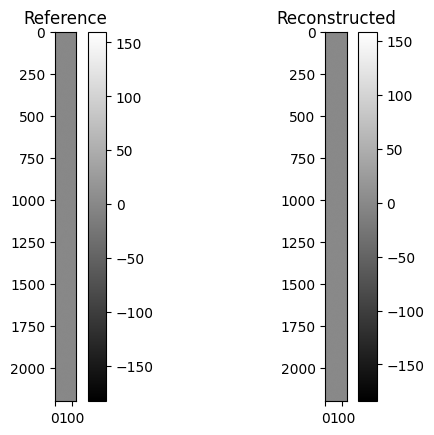

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(img_down, cmap='gray')
plt.colorbar()
plt.title('Reference')
plt.subplot(1, 2, 2)
plt.imshow(img_result, cmap='gray')
plt.colorbar()
plt.title('Reconstructed')

In [ ]:
print(f'Reference minimum: \t{img_down.min()},\tmaximum: {img_down.max()}')
print(f'Reconstructed minimum: \t{img_result.min()},\tmaximum: {img_result.max()}')

Reference minimum: 	-182.82730102539062,	maximum: 160.0046844482422
Reconstructed minimum: 	-184.10440063476562,	maximum: 158.6043701171875


In [ ]:
torch.cuda.empty_cache()

In [ ]:
sio.savemat("reconstruct_new256.mat", {"result":img_out})

In [ ]:
sio.savemat("reconstruct_sum128.mat", {"result":img_result})